In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# 1. Carga de datos

In [2]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [3]:
print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Number of classes: {len(labelNames)}")

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Number of classes: 100


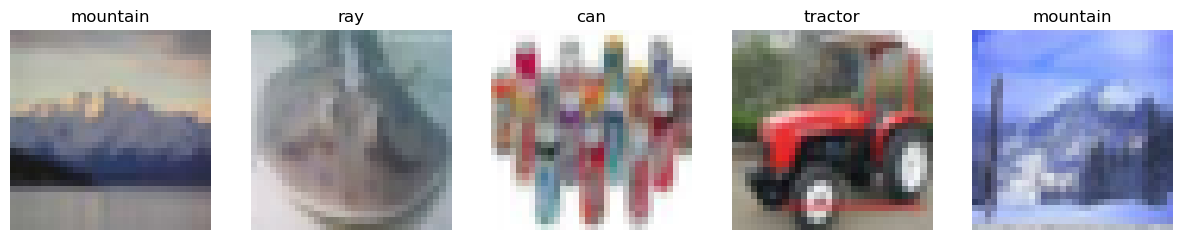

In [4]:
# Seleccionamos 5 índices aleatorios para mostrar las imágenes
num_images = 5
random_indices = np.random.choice(x_train.shape[0], num_images, replace=False)

# Visualizamos las imágenes seleccionadas aleatoriamente
fig, axes = plt.subplots(1, num_images, figsize=(15, 15))

for i, idx in enumerate(random_indices):
    ax = axes[i]
    ax.imshow(x_train[idx])  # Muestra la imagen
    ax.set_title(labelNames[y_train[idx][0]])  # Muestra la etiqueta
    ax.axis('off')  # Desactiva los ejes para mejor presentación

plt.show()

Comprobamos el formato de las etiquetas de entrenamiento

In [5]:
print(y_train[:5])  # Imprime las primeras 5 etiquetas de entrenamiento

[[19]
 [29]
 [ 0]
 [11]
 [ 1]]


# 2. Preprocesamiento de imagenes

In [6]:
x_train_resized = tf.image.resize(x_train, (224, 224))
x_test_resized = tf.image.resize(x_test, (224, 224))

In [7]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Definición del modelo preentrenado

In [8]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

In [9]:
base_model.trainable = False

In [10]:
model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(100, activation='softmax'))

In [11]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',  # Función de pérdida correcta para etiquetas enteras
              metrics=['accuracy'])

# 4. Entrenar el modelo

In [12]:
# Entrenamos el modelo
history = model.fit(x_train_resized, y_train,  # Conjunto de entrenamiento
                    validation_data=(x_test_resized, y_test),  # Validación en el conjunto de prueba
                    epochs=5,  # Número de épocas (ajusta según sea necesario)
                    batch_size=32)  # Tamaño del batch

Epoch 1/5
1188/1563 ━━━━━━━━━━━━━━━━━━━━ 2:12 355ms/step - accuracy: 0.3989 - loss: 2.4719

KeyboardInterrupt: 